# Data Cleaning & Preprocessing

This notebook documents every transformation applied before modelling:
- Dropping low-quality columns and rows with missing targets
- Imputing missing values
- Collapsing rare categories
- Outlier removal (IQR)
- Train/test split + StandardScaler + OneHotEncoder

All logic lives in `src/preprocessing.py` — imported here so models stay in sync.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from preprocessing import clean_data, remove_outliers_iqr, prepare_data

# Data Loading
df_raw = pd.read_csv('sample_kinder_data.csv')
print(f'Raw shape: {df_raw.shape}')

Raw shape: (5060, 14)


## Step 1 — clean_data()

Drops `ladder` and `schooldistrict_id`, imputes missing values, collapses rare categories.

In [2]:
df_clean = clean_data(df_raw)
print(f'After cleaning: {df_clean.shape}')
df_clean.isna().sum()

After cleaning: (4640, 12)


score_read     0
score_math     0
gender         0
birth          0
lunch          0
ethnicity      0
class_type     0
school         0
degree         0
experience     0
t_ethnicity    0
school_id      0
dtype: int64

In [3]:
# Verify category distributions after collapsing
for col in ['ethnicity', 'degree']:
    print(f'\n{col}:')
    print(df_clean[col].value_counts())


ethnicity:
ethnicity
cauc     3128
afam     1490
other      22
Name: count, dtype: int64

degree:
degree
bachelor    3005
master      1474
other        161
Name: count, dtype: int64


## Step 2 — Outlier Removal (IQR)

Remove rows where `score_read`, `score_math`, or `experience` are beyond 1.5×IQR.

In [4]:
df_no_out = df_clean.copy()
for col in ['score_read', 'score_math', 'experience']:
    before = len(df_no_out)
    df_no_out = remove_outliers_iqr(df_no_out, col)
    print(f'{col}: removed {before - len(df_no_out)} rows')

print(f'\nFinal shape: {df_no_out.shape}')

score_read: removed 114 rows
score_math: removed 35 rows
experience: removed 28 rows

Final shape: (4463, 12)


## Step 3 — Train/Test Split + Preprocessing Pipeline

In [5]:
(
    X_train, X_test,
    y_read_train, y_read_test,
    y_math_train, y_math_test,
    preprocessor, num_cols, cat_cols
) = prepare_data(df_raw)

print(f'Train size : {X_train.shape[0]}')
print(f'Test size  : {X_test.shape[0]}')
print(f'Numeric features : {list(num_cols)}')
print(f'Categorical features: {list(cat_cols)}')

Train size : 3570
Test size  : 893
Numeric features : ['experience', 'school_id']
Categorical features: ['gender', 'birth', 'lunch', 'ethnicity', 'class_type', 'school', 'degree', 't_ethnicity']


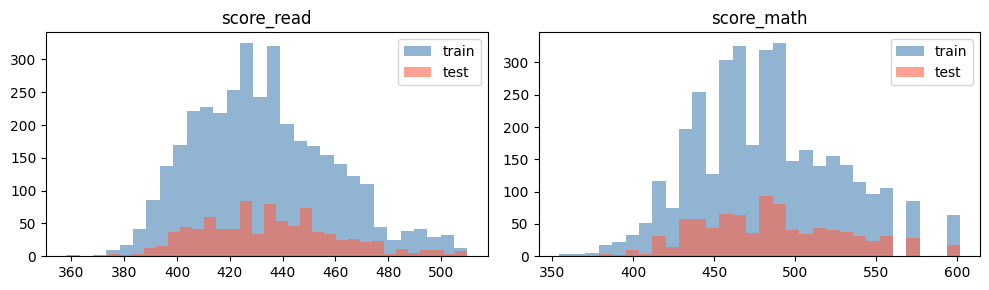

In [6]:
# Sanity check: target distributions in train vs test
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, (train_y, test_y, label) in zip(axes, [
    (y_read_train, y_read_test, 'score_read'),
    (y_math_train, y_math_test, 'score_math')
]):
    ax.hist(train_y, bins=30, alpha=0.6, label='train', color='steelblue')
    ax.hist(test_y,  bins=30, alpha=0.6, label='test',  color='tomato')
    ax.set_title(label)
    ax.legend()
plt.tight_layout()
plt.show()

In [7]:
df_no_out.to_csv('kinder_clean.csv', index=False)
print(f'Saved cleaned dataset: {df_no_out.shape}')

Saved cleaned dataset: (4463, 12)
